# Active Learning for Frame Weights - Kidney Allocation
"""
This notebook implements an active learning algorithm to learn frame weights 
in a multi-frame preference model for kidney allocation decisions.

Based on adapting volume-removal active learning (Sadigh et al. 2017) to linear frames.
"""

In [103]:
# Imports
import numpy as np
import pandas as pd
from typing import List, Tuple, Dict, Set, Optional
from dataclasses import dataclass
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
import seaborn as sns

sns.set_style("whitegrid")
np.random.seed(42)

In [104]:
# Feature configuration for kidney allocation domain
FEATURE_NAMES = ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']

# Feature ranges extracted from kidney_pairwise_data.csv
FEATURE_RANGES = {
    'elderlyDep': (0, 3),
    'lifeYearsGained': (0, 25),  # -1 might be missing data indicator
    'obesity': (0, 4),  # Categorical: 0=not obese to 4=very obese  
    'weeklyWorkhours': (0, 50),
    'yearsWaiting': (1, 7)
}

# Algorithm parameters
TAU = 1.0  # Intensity threshold
TAU_PRIME = 0.2  # Resolvability threshold
LAMBDA_X = 1.0  # Query scaling factor (can be a function later)

print("Configuration:")
print(f"  Features: {FEATURE_NAMES}")
print(f"  Thresholds: τ={TAU}, τ'={TAU_PRIME}")
print(f"  λ(X) = {LAMBDA_X}")

Configuration:
  Features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
  Thresholds: τ=1.0, τ'=0.2
  λ(X) = 1.0


In [105]:
# Data structures: Patient
@dataclass
class Patient:
    """Represents a patient with feature values."""
    elderlyDep: int
    lifeYearsGained: float
    obesity: int
    weeklyWorkhours: int
    yearsWaiting: int

    def to_array(self) -> np.ndarray:
        """Convert to numpy array in standard feature order."""
        return np.array([
            self.elderlyDep,
            self.lifeYearsGained,
            self.obesity,
            self.weeklyWorkhours,
            self.yearsWaiting
        ], dtype=float)

    @classmethod
    def from_array(cls, arr: np.ndarray) -> 'Patient':
        """Create Patient from numpy array."""
        return cls(
            elderlyDep=int(arr[0]),
            lifeYearsGained=float(arr[1]),
            obesity=int(arr[2]),
            weeklyWorkhours=int(arr[3]),
            yearsWaiting=int(arr[4])
        )

    def __repr__(self):
        return f"Patient(elder={self.elderlyDep}, life={self.lifeYearsGained}, " \
               f"obesity={self.obesity}, work={self.weeklyWorkhours}, wait={self.yearsWaiting})"

# Test
p = Patient(elderlyDep=2, lifeYearsGained=15, obesity=1, weeklyWorkhours=40, yearsWaiting=3)
print(p)
print(f"As array: {p.to_array()}")

Patient(elder=2, life=15, obesity=1, work=40, wait=3)
As array: [ 2. 15.  1. 40.  3.]


In [106]:
# Data structures: PairwiseQuery and QueryResponse
@dataclass
class PairwiseQuery:
    """Represents a pairwise comparison query."""
    patient_left: Patient
    patient_right: Patient
    context: Optional[str] = None  # Optional context information X

    def __repr__(self):
        return f"Query:\n  LEFT:  {self.patient_left}\n  RIGHT: {self.patient_right}"


@dataclass
class QueryResponse:
    """Response to a pairwise query."""
    choice: str  # 'left', 'right', 'indifferent', 'incomparable'
    active_frames: Set[int]  # Which frames were active (0-indexed)

    def __repr__(self):
        return f"Response(choice={self.choice}, active_frames={self.active_frames})"

# Test
p1 = Patient(elderlyDep=2, lifeYearsGained=15, obesity=1, weeklyWorkhours=40, yearsWaiting=3)
p2 = Patient(elderlyDep=0, lifeYearsGained=20, obesity=3, weeklyWorkhours=30, yearsWaiting=5)
query = PairwiseQuery(p1, p2)
print(query)
print()
response = QueryResponse(choice='left', active_frames={0, 1, 4})
print(response)

Query:
  LEFT:  Patient(elder=2, life=15, obesity=1, work=40, wait=3)
  RIGHT: Patient(elder=0, life=20, obesity=3, work=30, wait=5)

Response(choice=left, active_frames={0, 1, 4})


In [107]:
# Simplex sampling: sample_from_simplex
def sample_from_simplex(n_samples: int, dim: int,
                       active_frames: Optional[Set[int]] = None,
                       random_state: Optional[int] = None) -> np.ndarray:
    """
    Sample uniformly from the probability simplex.

    Uses the Dirichlet distribution with α=1 (uniform on simplex).

    Parameters:
    -----------
    n_samples : int
        Number of samples to generate
    dim : int
        Dimension of simplex (number of frames)
    active_frames : Set[int], optional
        If provided, only these frames can have non-zero weight
    random_state : int, optional
        Random seed for reproducibility

    Returns:
    --------
    samples : np.ndarray, shape (n_samples, dim)
        Samples from the simplex, each row sums to 1
    """
    if random_state is not None:
        np.random.seed(random_state)

    if active_frames is None:
        # Sample from full simplex
        samples = np.random.dirichlet(np.ones(dim), size=n_samples)
    else:
        # Only sample on sub-simplex for active frames
        samples = np.zeros((n_samples, dim))
        active_list = sorted(list(active_frames))
        n_active = len(active_list)

        if n_active == 0:
            raise ValueError("Must have at least one active frame")

        # Sample from sub-simplex
        sub_samples = np.random.dirichlet(np.ones(n_active), size=n_samples)

        # Place in correct positions
        for i, frame_idx in enumerate(active_list):
            samples[:, frame_idx] = sub_samples[:, i]

    return samples

# Test
samples = sample_from_simplex(10, 5, random_state=42)
print("Full simplex samples:")
print(samples[:3])
print(f"Row sums: {samples.sum(axis=1)[:3]}")
print()
samples_subset = sample_from_simplex(10, 5, active_frames={0, 2, 4}, random_state=42)
print("Sub-simplex samples (frames {0, 2, 4} only):")
print(samples_subset[:3])

Full simplex samples:
[[0.07982511 0.51203839 0.22398576 0.1552966  0.02885413]
 [0.03862363 0.0136276  0.45803501 0.20931053 0.28040323]
 [0.00361717 0.60929814 0.31067514 0.04150979 0.03489977]]
Row sums: [1. 1. 1.]

Sub-simplex samples (frames {0, 2, 4} only):
[[0.09784297 0.         0.62761396 0.         0.27454307]
 [0.729092   0.         0.13546541 0.         0.13544259]
 [0.02001195 0.         0.67261832 0.         0.30736973]]


In [108]:
# Simplex sampling: resample_from_feasible_set
def resample_from_feasible_set(existing_samples: np.ndarray,
                               target_n_samples: int,
                               noise_scale: float = 0.05) -> np.ndarray:
    """
    Generate new samples by perturbing existing feasible samples.

    This is used when we've filtered out too many samples and need to replenish.

    Parameters:
    -----------
    existing_samples : np.ndarray, shape (n_existing, dim)
        Current feasible samples
    target_n_samples : int
        Desired number of samples
    noise_scale : float
        Scale of Gaussian noise to add before re-normalizing

    Returns:
    --------
    new_samples : np.ndarray, shape (target_n_samples, dim)
        Resampled feasible set
    """
    n_existing, dim = existing_samples.shape

    # Resample with replacement
    indices = np.random.choice(n_existing, size=target_n_samples, replace=True)
    new_samples = existing_samples[indices].copy()

    # Add noise and re-project to simplex
    noise = np.random.randn(target_n_samples, dim) * noise_scale
    new_samples = new_samples + noise
    new_samples = np.maximum(new_samples, 0)  # Ensure non-negative

    # Re-normalize to simplex
    row_sums = new_samples.sum(axis=1, keepdims=True)
    new_samples = new_samples / np.maximum(row_sums, 1e-10)

    return new_samples

# Test
small_samples = sample_from_simplex(5, 5, random_state=42)
print("Original 5 samples:")
print(small_samples)
print()
resampled = resample_from_feasible_set(small_samples, target_n_samples=10, noise_scale=0.05)
print("Resampled to 10:")
print(resampled)

Original 5 samples:
[[0.07982511 0.51203839 0.22398576 0.1552966  0.02885413]
 [0.03862363 0.0136276  0.45803501 0.20931053 0.28040323]
 [0.00361717 0.60929814 0.31067514 0.04150979 0.03489977]
 [0.09130535 0.16347231 0.33524563 0.25485514 0.15512157]
 [0.37744127 0.05991806 0.13780201 0.18197713 0.24286153]]

Resampled to 10:
[[0.         0.66221368 0.32797237 0.00981396 0.        ]
 [0.08553135 0.14059315 0.34428266 0.25014958 0.17944326]
 [0.0233575  0.18159446 0.39484708 0.26192367 0.13827728]
 [0.13377982 0.49833804 0.15635252 0.20942753 0.00210209]
 [0.         0.60673709 0.27279197 0.05176951 0.06870143]
 [0.38866694 0.0964089  0.16175102 0.15812714 0.19504599]
 [0.         0.61453668 0.27918948 0.01941877 0.08685508]
 [0.34784446 0.10633934 0.15965895 0.13607629 0.25008097]
 [0.09525546 0.40914105 0.22151128 0.12768048 0.14641173]
 [0.         0.         0.49140882 0.14944822 0.35914295]]


In [109]:
# Simplex sampling: compute_diameter
def compute_diameter(samples: np.ndarray, norm: str = 'l1') -> float:
    """
    Compute diameter of a set of samples.

    Parameters:
    -----------
    samples : np.ndarray, shape (n_samples, dim)
        Sample points
    norm : str
        Which norm to use: 'l1', 'l2', or 'linf'

    Returns:
    --------
    diameter : float
        Maximum pairwise distance
    """
    if len(samples) == 0:
        return 0.0

    if len(samples) == 1:
        return 0.0

    # Compute all pairwise distances
    if norm == 'l1':
        p = 1
    elif norm == 'l2':
        p = 2
    elif norm == 'linf':
        p = np.inf
    else:
        raise ValueError(f"Unknown norm: {norm}")

    distances = pdist(samples, metric='minkowski', p=p)

    return distances.max()

# Test
samples = sample_from_simplex(100, 5, random_state=42)
print(f"Diameter (L1) of 100 samples on 5D simplex: {compute_diameter(samples, 'l1'):.4f}")
print(f"Diameter (L2) of 100 samples on 5D simplex: {compute_diameter(samples, 'l2'):.4f}")

# Smaller feasible set
small_samples = sample_from_simplex(100, 5, active_frames={0, 1}, random_state=42)
print(f"\nDiameter (L1) when only 2 frames active: {compute_diameter(small_samples, 'l1'):.4f}")

Diameter (L1) of 100 samples on 5D simplex: 1.8028
Diameter (L2) of 100 samples on 5D simplex: 1.0742

Diameter (L1) when only 2 frames active: 1.9643


In [110]:
# Query generation: generate_random_patient
def generate_random_patient() -> Patient:
    """Generate a random patient with features in valid ranges."""
    return Patient(
        elderlyDep=np.random.randint(0, 4),
        lifeYearsGained=np.random.randint(-1, 26),
        obesity=np.random.randint(0, 5),
        weeklyWorkhours=np.random.randint(0, 51),
        yearsWaiting=np.random.randint(1, 8)
    )

# Test
print("Random patients:")
for _ in range(3):
    print(f"  {generate_random_patient()}")

Random patients:
  Patient(elder=3, life=18, obesity=2, work=48, wait=4)
  Patient(elder=1, life=6, obesity=3, work=34, wait=6)
  Patient(elder=0, life=1, obesity=0, work=28, wait=2)


In [111]:
# Core computations: compute_frame_gaps
def compute_frame_gaps(query: PairwiseQuery,
                      lambda_x: float = LAMBDA_X,
                      tau: float = TAU) -> Tuple[np.ndarray, Set[int]]:
    """
    Compute frame-level gaps and identify active (decisive) frames for a query.

    In the linear setting with V = I:
        Δ_j = λ(X) × [feature_j(left) - feature_j(right)]

    For a frame j:
        s^+_j = max(Δ_j, 0)
        s^-_j = max(-Δ_j, 0)

    A frame j is active (decisive) if s^+_j + s^-_j ≥ τ, i.e., |Δ_j| ≥ τ

    Parameters:
    -----------
    query : PairwiseQuery
        The pairwise comparison query
    lambda_x : float
        Query scaling factor (default: LAMBDA_X)
    tau : float
        Intensity threshold (default: TAU)

    Returns:
    --------
    gaps : np.ndarray, shape (n_frames,)
        Frame-level preference gaps Δ_j
    active_frames : Set[int]
        Indices of frames where |Δ_j| ≥ τ (frame is decisive)
    """
    # Get feature vectors
    left_features = query.patient_left.to_array()
    right_features = query.patient_right.to_array()

    # Compute gaps: Δ_j = λ(X) × (left - right)
    gaps = lambda_x * (left_features - right_features)

    # Identify active frames: frame j is active if |Δ_j| ≥ τ
    active_frames = set(np.where(np.abs(gaps) >= tau)[0].tolist())

    return gaps, active_frames

# Test
p1 = Patient(elderlyDep=2, lifeYearsGained=15, obesity=1, weeklyWorkhours=40, yearsWaiting=3)
p2 = Patient(elderlyDep=0, lifeYearsGained=20, obesity=3, weeklyWorkhours=30, yearsWaiting=5)
query = PairwiseQuery(p1, p2)

gaps, active = compute_frame_gaps(query)
print(f"Query: elder={p1.elderlyDep} vs {p2.elderlyDep}, life={p1.lifeYearsGained} vs {p2.lifeYearsGained}")
print(f"Frame gaps Δ: {gaps}")
print(f"Active frames (|Δ_j| ≥ {TAU}): {sorted(active)}")
print(f"  Features: {[FEATURE_NAMES[i] for i in sorted(active)]}")

Query: elder=2 vs 0, life=15 vs 20
Frame gaps Δ: [ 2. -5. -2. 10. -2.]
Active frames (|Δ_j| ≥ 1.0): [0, 1, 2, 3, 4]
  Features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']


In [112]:
# Core computations: compute_aggregate_scores
def compute_aggregate_scores(gaps: np.ndarray, 
                             weights: np.ndarray,
                             active_frames: Set[int]) -> Tuple[float, float]:
    """
    Compute aggregate preference score and intensity for given weights.
    
    For a weight vector ω and frame gaps Δ:
        Δ(ω) = Σ_{j∈active} ω_j × Δ_j    (signed preference)
        r(ω) = Σ_{j∈active} ω_j × |Δ_j|  (intensity, always >= 0)
    
    Parameters:
    -----------
    gaps : np.ndarray, shape (n_frames,)
        Frame-level preference gaps Δ_j
    weights : np.ndarray, shape (n_frames,)
        Frame weights ω (should sum to 1)
    active_frames : Set[int]
        Indices of active frames
    
    Returns:
    --------
    delta_omega : float
        Aggregate preference score Δ(ω)
    r_omega : float
        Aggregate intensity r(ω)
    """
    if len(active_frames) == 0:
        return 0.0, 0.0
    
    # Only consider active frames
    active_list = sorted(list(active_frames))
    active_gaps = gaps[active_list]
    active_weights = weights[active_list]
    
    # Compute weighted sums
    delta_omega = np.dot(active_weights, active_gaps)
    r_omega = np.dot(active_weights, np.abs(active_gaps))
    
    return delta_omega, r_omega

# Test
gaps = np.array([2.0, -5.0, -2.0, 10.0, -2.0])  # Frame gaps
active = {0, 1, 3, 4}  # Frames 0, 1, 3, 4 are active
weights = np.array([0.2, 0.3, 0.0, 0.4, 0.1])  # Weight on simplex

delta, r = compute_aggregate_scores(gaps, weights, active)
print(f"Gaps: {gaps}")
print(f"Weights: {weights}")
print(f"Active frames: {sorted(active)}")
print(f"Δ(ω) = {delta:.3f} (signed preference)")
print(f"r(ω) = {r:.3f} (intensity)")
print(f"\nManual check:")
print(f"  Δ(ω) = 0.2×{gaps[0]} + 0.3×{gaps[1]} + 0.4×{gaps[3]} + 0.1×{gaps[4]} = {0.2*gaps[0] + 0.3*gaps[1] + 0.4*gaps[3] + 0.1*gaps[4]:.3f}")

Gaps: [ 2. -5. -2. 10. -2.]
Weights: [0.2 0.3 0.  0.4 0.1]
Active frames: [0, 1, 3, 4]
Δ(ω) = 2.700 (signed preference)
r(ω) = 6.100 (intensity)

Manual check:
  Δ(ω) = 0.2×2.0 + 0.3×-5.0 + 0.4×10.0 + 0.1×-2.0 = 2.700


In [113]:
# Core computations: predict_response
def predict_response(query: PairwiseQuery,
                    weights: np.ndarray,
                    tau: float = TAU,
                    lambda_x: float = LAMBDA_X,
                    tau_prime: float = TAU_PRIME) -> str:
    """
    Predict the response for a query given a weight vector.
    
    Decision rule:
        - If r(ω) ≤ τ: 'incomparable' (intensity too low)
        - Else if |Δ(ω)| / r(ω) < τ': 'incomparable' (not resolvable)
        - Else if Δ(ω) > 0: 'left' (prefer left patient)
        - Else if Δ(ω) < 0: 'right' (prefer right patient)
        - Else: 'indifferent' (Δ(ω) = 0)
    
    Parameters:
    -----------
    query : PairwiseQuery
        The pairwise comparison query
    weights : np.ndarray, shape (n_frames,)
        Frame weights ω
    tau : float
        Intensity threshold (default: TAU)
    lambda_x : float
        Query scaling factor (default: LAMBDA_X)
    tau_prime : float
        Resolvability threshold (default: TAU_PRIME)
    
    Returns:
    --------
    response : str
        One of: 'left', 'right', 'indifferent', 'incomparable'
    """
    # Compute frame gaps and active frames
    gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)
    
    # Compute aggregate scores
    delta_omega, r_omega = compute_aggregate_scores(gaps, weights, active_frames)
    
    # Apply decision rule
    if r_omega <= tau:
        return 'incomparable'
    if r_omega > tau and np.abs(delta_omega) < tau_prime * r_omega:
        # Not resolvable: |Δ(ω)| < τ' * r(ω)
        return 'incomparable'
    elif r_omega > tau and delta_omega > 0:
        return 'left'
    elif r_omega > tau and delta_omega < 0:
        return 'right'
    else:
        return 'indifferent'

# Test
p1 = Patient(elderlyDep=2, lifeYearsGained=0, obesity=1, weeklyWorkhours=40, yearsWaiting=5)
p2 = Patient(elderlyDep=0, lifeYearsGained=15, obesity=3, weeklyWorkhours=30, yearsWaiting=3)
query = PairwiseQuery(p1, p2)

# Test different weight vectors
w1 = np.array([0.6, 0.1, 0.1, 0.1, 0.1])  # Heavy on elderlyDep (frame 0)
w2 = np.array([0.1, 0.6, 0.1, 0.1, 0.1])  # Heavy on lifeYearsGained (frame 1)
w3 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])  # Uniform

print(f"Query: {p1} vs {p2}")
print(f"\nWeight w1 (heavy on elderlyDep): {w1}")
print(f"  Predicted response: {predict_response(query, w1)}")
print(f"\nWeight w2 (heavy on lifeYearsGained): {w2}")
print(f"  Predicted response: {predict_response(query, w2)}")
print(f"\nWeight w3 (uniform): {w3}")
print(f"  Predicted response: {predict_response(query, w3)}")

Query: Patient(elder=2, life=0, obesity=1, work=40, wait=5) vs Patient(elder=0, life=15, obesity=3, work=30, wait=3)

Weight w1 (heavy on elderlyDep): [0.6 0.1 0.1 0.1 0.1]
  Predicted response: incomparable

Weight w2 (heavy on lifeYearsGained): [0.1 0.6 0.1 0.1 0.1]
  Predicted response: right

Weight w3 (uniform): [0.2 0.2 0.2 0.2 0.2]
  Predicted response: incomparable


In [114]:
# Volume removal: filter_samples_by_response
def filter_samples_by_response(samples: np.ndarray,
                               query: PairwiseQuery,
                               observed_response: str,
                               tau: float = TAU,
                               lambda_x: float = LAMBDA_X,
                               tau_prime: float = TAU_PRIME) -> np.ndarray:
    """
    Filter samples to keep only those consistent with observed response.
    
    This is the volume removal step: we eliminate all weight vectors
    that would have predicted a different response.
    
    Parameters:
    -----------
    samples : np.ndarray, shape (n_samples, dim)
        Current feasible weight vectors
    query : PairwiseQuery
        The query that was asked
    observed_response : str
        The response observed: 'left', 'right', 'indifferent', or 'incomparable'
    tau : float
        Intensity threshold
    lambda_x : float
        Query scaling factor
    tau_prime : float
        Resolvability threshold
    
    Returns:
    --------
    filtered_samples : np.ndarray, shape (n_consistent, dim)
        Weight vectors consistent with the observed response
    """
    # Compute gaps and active frames once
    gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)
    
    # Vectorized computation of aggregate scores for all samples
    if len(active_frames) == 0:
        # No active frames - all would respond 'incomparable'
        if observed_response == 'incomparable':
            return samples
        else:
            return np.empty((0, samples.shape[1]))
    
    active_list = sorted(list(active_frames))
    active_gaps = gaps[active_list]
    
    # Compute delta_omega and r_omega for all samples at once
    active_weights = samples[:, active_list]
    delta_omegas = np.dot(active_weights, active_gaps)
    r_omegas = np.dot(active_weights, np.abs(active_gaps))
    
    # Determine predicted responses for all samples
    # Start with all 'incomparable'
    predicted = np.full(len(samples), 'incomparable', dtype=object)
    
    # Check intensity and resolvability
    high_intensity = r_omegas > tau
    resolvable = np.abs(delta_omegas) >= tau_prime * r_omegas
    
    # Update based on conditions
    decisive = high_intensity & resolvable
    predicted[decisive & (delta_omegas > 0)] = 'left'
    predicted[decisive & (delta_omegas < 0)] = 'right'
    predicted[decisive & (delta_omegas == 0)] = 'indifferent'
    
    # Keep only consistent samples
    consistent_mask = (predicted == observed_response)
    filtered_samples = samples[consistent_mask]
    
    return filtered_samples

# Test
samples = sample_from_simplex(1000, 5, random_state=42)
p1 = Patient(elderlyDep=2, lifeYearsGained=20, obesity=1, weeklyWorkhours=40, yearsWaiting=5)
p2 = Patient(elderlyDep=0, lifeYearsGained=15, obesity=3, weeklyWorkhours=30, yearsWaiting=3)
query = PairwiseQuery(p1, p2)

print(f"Initial samples: {len(samples)}")

# Simulate observing "left" response
filtered = filter_samples_by_response(samples, query, 'left')
print(f"After observing 'left': {len(filtered)} samples remaining ({100*len(filtered)/len(samples):.1f}%)")

# Further filter with another query
p3 = Patient(elderlyDep=3, lifeYearsGained=10, obesity=4, weeklyWorkhours=20, yearsWaiting=7)
p4 = Patient(elderlyDep=1, lifeYearsGained=25, obesity=0, weeklyWorkhours=50, yearsWaiting=1)
query2 = PairwiseQuery(p3, p4)
filtered2 = filter_samples_by_response(filtered, query2, 'right')
print(f"After observing 'right' to 2nd query: {len(filtered2)} samples ({100*len(filtered2)/len(samples):.1f}%)")

Initial samples: 1000
After observing 'left': 976 samples remaining (97.6%)
After observing 'right' to 2nd query: 811 samples (81.1%)


In [115]:
# Query generation: generate_query_activating_frames
def generate_query_activating_frames(target_frames: Set[int],
                                    lambda_x: float = LAMBDA_X,
                                    tau: float = TAU,
                                    min_gap: float = None,
                                    max_attempts: int = 100) -> Optional[PairwiseQuery]:
    """
    Generate a query that activates a specific subset of frames.
    
    Strategy:
    - For frames in target_frames: set |Δ_j| ≥ τ (make them active/decisive)
    - For frames not in target_frames: set |Δ_j| < τ (make them inactive)
    
    Parameters:
    -----------
    target_frames : Set[int]
        Indices of frames to activate (0-indexed)
    lambda_x : float
        Query scaling factor
    tau : float
        Intensity threshold
    min_gap : float, optional
        Minimum gap for active frames (default: 1.5 * tau)
    max_attempts : int
        Maximum number of random attempts
    
    Returns:
    --------
    query : PairwiseQuery or None
        A query activating the target frames, or None if failed
    """
    if min_gap is None:
        min_gap = 1.5 * tau
    
    n_features = len(FEATURE_NAMES)
    
    for attempt in range(max_attempts):
        # Generate random left patient
        left = generate_random_patient()
        left_arr = left.to_array()
        
        # Construct right patient to achieve desired activation
        right_arr = left_arr.copy()
        
        for j in range(n_features):
            feature_name = FEATURE_NAMES[j]
            min_val, max_val = FEATURE_RANGES[feature_name]
            
            if j in target_frames:
                # Make this frame active: |Δ_j| ≥ τ
                # Need |left[j] - right[j]| * lambda_x >= tau
                required_diff = min_gap / lambda_x
                
                # Try to create difference
                if left_arr[j] + required_diff <= max_val:
                    right_arr[j] = left_arr[j] - required_diff
                elif left_arr[j] - required_diff >= min_val:
                    right_arr[j] = left_arr[j] + required_diff
                else:
                    # Can't achieve required difference - try next attempt
                    break
            else:
                # Make this frame inactive: |Δ_j| < τ
                # Set right[j] ≈ left[j] (small or no difference)
                max_diff = tau / lambda_x * 0.8  # Stay safely below threshold
                diff = np.random.uniform(-max_diff, max_diff)
                right_arr[j] = np.clip(left_arr[j] + diff, min_val, max_val)
        else:
            # All features successfully set - validate
            right = Patient.from_array(right_arr)
            query = PairwiseQuery(left, right)
            
            # Check if it actually activates the correct frames
            _, active = compute_frame_gaps(query, lambda_x, tau)
            if active == target_frames:
                return query
    
    # Failed to generate query after max_attempts
    return None

# Test
print("Generating queries with specific frame activations:\n")

# Query activating only frames {0, 2} (elderlyDep, obesity)
query1 = generate_query_activating_frames({0, 2})
if query1:
    gaps, active = compute_frame_gaps(query1)
    print(f"Target frames: {{0, 2}}")
    print(f"  {query1}")
    print(f"  Gaps: {gaps}")
    print(f"  Active: {active} ✓" if active == {0, 2} else f"  Active: {active} ✗")

print()

# Query activating frames {1, 4} (lifeYearsGained, yearsWaiting)
query2 = generate_query_activating_frames({1, 4})
if query2:
    gaps, active = compute_frame_gaps(query2)
    print(f"Target frames: {{1, 4}}")
    print(f"  {query2}")
    print(f"  Gaps: {gaps}")
    print(f"  Active: {active} ✓" if active == {1, 4} else f"  Active: {active} ✗")

Generating queries with specific frame activations:

Target frames: {0, 2}
  Query:
  LEFT:  Patient(elder=2, life=3, obesity=2, work=14, wait=3)
  RIGHT: Patient(elder=3, life=2.464799639461849, obesity=0, work=14, wait=3)
  Gaps: [-1.          0.53520036  2.          0.          0.        ]
  Active: {0, 2} ✓

Target frames: {1, 4}
  Query:
  LEFT:  Patient(elder=2, life=1, obesity=4, work=5, wait=1)
  RIGHT: Patient(elder=2, life=-0.5, obesity=4, work=5, wait=0)
  Gaps: [0.  1.5 0.  0.  1. ]
  Active: {1, 4} ✓


In [116]:
# Query generation: generate_candidate_queries
def generate_candidate_queries(n_candidates: int = 50,
                               n_features: int = 5,
                               max_active: int = None) -> List[PairwiseQuery]:
    """
    Generate a diverse pool of candidate queries.
    
    Strategy:
    - Sample different frame activation patterns
    - Generate queries for each pattern
    - Prioritize patterns with moderate numbers of active frames
    
    Parameters:
    -----------
    n_candidates : int
        Target number of candidate queries
    n_features : int
        Number of features/frames
    max_active : int, optional
        Maximum number of active frames (default: n_features)
    
    Returns:
    --------
    candidates : List[PairwiseQuery]
        List of candidate queries
    """
    if max_active is None:
        max_active = n_features
    
    candidates = []
    attempted_patterns = set()
    
    # Try to generate diverse activation patterns
    max_attempts = n_candidates * 3
    
    for _ in range(max_attempts):
        if len(candidates) >= n_candidates:
            break
        
        # Choose number of active frames (prefer 2-4)
        if np.random.random() < 0.7:
            # Moderate number
            n_active = np.random.randint(2, min(5, max_active + 1))
        else:
            # Full range
            n_active = np.random.randint(1, max_active + 1)
        
        # Sample which frames to activate
        target_frames = set(np.random.choice(n_features, size=n_active, replace=False).tolist())
        
        # Skip if we've tried this pattern
        pattern_key = frozenset(target_frames)
        if pattern_key in attempted_patterns:
            continue
        
        attempted_patterns.add(pattern_key)
        
        # Try to generate query
        query = generate_query_activating_frames(target_frames)
        if query is not None:
            candidates.append(query)
    
    # If we didn't get enough, add some random queries
    while len(candidates) < n_candidates * 0.5:
        left = generate_random_patient()
        right = generate_random_patient()
        candidates.append(PairwiseQuery(left, right))
    
    return candidates

# Test
print("Generating candidate queries...\n")
candidates = generate_candidate_queries(n_candidates=20)

print(f"Generated {len(candidates)} candidate queries\n")

# Analyze activation patterns
activation_counts = {}
for query in candidates:
    _, active = compute_frame_gaps(query)
    n_active = len(active)
    activation_counts[n_active] = activation_counts.get(n_active, 0) + 1

print("Distribution of active frame counts:")
for n_active in sorted(activation_counts.keys()):
    print(f"  {n_active} frames active: {activation_counts[n_active]} queries")

# Show a few examples
print(f"\nFirst 3 candidate queries:")
for i, query in enumerate(candidates[:3]):
    gaps, active = compute_frame_gaps(query)
    print(f"\n{i+1}. Active frames: {sorted(active)}")
    print(f"   {query}")
    print(f"   Gaps: {gaps}")

Generating candidate queries...

Generated 20 candidate queries

Distribution of active frame counts:
  1 frames active: 3 queries
  2 frames active: 7 queries
  3 frames active: 5 queries
  4 frames active: 4 queries
  5 frames active: 1 queries

First 3 candidate queries:

1. Active frames: [0, 1]
   Query:
  LEFT:  Patient(elder=1, life=11, obesity=1, work=41, wait=5)
  RIGHT: Patient(elder=0, life=9.5, obesity=1, work=41, wait=5)
   Gaps: [1.  1.5 0.  0.  0. ]

2. Active frames: [0]
   Query:
  LEFT:  Patient(elder=0, life=1, obesity=1, work=39, wait=3)
  RIGHT: Patient(elder=-1, life=0.3637873353331349, obesity=1, work=39, wait=3)
   Gaps: [1.         0.63621266 0.         0.         0.        ]

3. Active frames: [0, 4]
   Query:
  LEFT:  Patient(elder=2, life=24, obesity=1, work=23, wait=4)
  RIGHT: Patient(elder=3, life=23.401784515800657, obesity=1, work=23, wait=2)
   Gaps: [-1.          0.59821548  0.          0.          2.        ]


In [117]:
# Query selection: select_query_by_uncertainty
def select_query_by_uncertainty(candidates: List[PairwiseQuery],
                                samples: np.ndarray,
                                tau: float = TAU,
                                lambda_x: float = LAMBDA_X,
                                tau_prime: float = TAU_PRIME) -> Tuple[PairwiseQuery, Dict[str, float]]:
    """
    Select the query that maximizes uncertainty (best splits the feasible set).
    
    For each candidate query, we:
    1. Predict responses for all samples in the feasible set
    2. Compute uncertainty based on response distribution
    3. Select query with highest uncertainty
    
    Uncertainty measure: entropy of response distribution
        H = -Σ p_r log(p_r) where p_r = fraction predicting response r
    
    Parameters:
    -----------
    candidates : List[PairwiseQuery]
        Candidate queries to choose from
    samples : np.ndarray, shape (n_samples, dim)
        Current feasible weight vectors
    tau : float
        Intensity threshold
    lambda_x : float
        Query scaling factor
    tau_prime : float
        Resolvability threshold
    
    Returns:
    --------
    best_query : PairwiseQuery
        Query with highest uncertainty
    info : Dict[str, float]
        Information about the selected query (uncertainty, response counts)
    """
    if len(candidates) == 0:
        raise ValueError("No candidate queries provided")
    
    if len(samples) == 0:
        # No samples - just return first candidate
        return candidates[0], {'uncertainty': 0.0}
    
    best_query = None
    best_uncertainty = -1
    best_info = {}
    
    for query in candidates:
        # Compute gaps and active frames once
        gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)
        
        if len(active_frames) == 0:
            # All samples would respond 'incomparable' - no information
            continue
        
        # Vectorized prediction for all samples
        active_list = sorted(list(active_frames))
        active_gaps = gaps[active_list]
        active_weights = samples[:, active_list]
        
        delta_omegas = np.dot(active_weights, active_gaps)
        r_omegas = np.dot(active_weights, np.abs(active_gaps))
        
        # Count responses using same logic as filter_samples_by_response
        response_counts = {'left': 0, 'right': 0, 'indifferent': 0, 'incomparable': 0}
        
        # Check intensity and resolvability
        high_intensity = r_omegas > tau
        resolvable = np.abs(delta_omegas) >= tau_prime * r_omegas
        
        # Classify responses
        for i in range(len(samples)):
            if not high_intensity[i] or not resolvable[i]:
                response_counts['incomparable'] += 1
            elif delta_omegas[i] > 0:
                response_counts['left'] += 1
            elif delta_omegas[i] < 0:
                response_counts['right'] += 1
            else:
                response_counts['indifferent'] += 1
        
        # Compute entropy
        total = len(samples)
        probs = [count / total for count in response_counts.values() if count > 0]
        
        if len(probs) <= 1:
            # All samples predict same response - no uncertainty
            uncertainty = 0.0
        else:
            # Entropy: H = -Σ p log(p)
            uncertainty = -sum(p * np.log2(p) for p in probs)
        
        # Track best
        if uncertainty > best_uncertainty:
            best_uncertainty = uncertainty
            best_query = query
            best_info = {
                'uncertainty': uncertainty,
                'response_counts': response_counts.copy(),
                'active_frames': active_frames
            }
    
    if best_query is None:
        # Fallback: return first candidate
        best_query = candidates[0]
        best_info = {'uncertainty': 0.0}
    
    return best_query, best_info

# Test
samples = sample_from_simplex(1000, 5, random_state=42)
candidates = generate_candidate_queries(n_candidates=10)

print(f"Selecting query from {len(candidates)} candidates...\n")

best_query, info = select_query_by_uncertainty(candidates, samples)

print(f"Selected query:")
print(f"{best_query}")
print(f"\nUncertainty: {info['uncertainty']:.3f} bits")
print(f"Active frames: {sorted(info.get('active_frames', set()))}")
print(f"Response distribution:")
for response, count in info.get('response_counts', {}).items():
    if count > 0:
        pct = 100 * count / len(samples)
        print(f"  {response}: {count} ({pct:.1f}%)")

Selecting query from 10 candidates...

Selected query:
Query:
  LEFT:  Patient(elder=2, life=24, obesity=4, work=22, wait=5)
  RIGHT: Patient(elder=3, life=25.5, obesity=4, work=20, wait=3)

Uncertainty: 1.465 bits
Active frames: [0, 1, 3, 4]
Response distribution:
  left: 464 (46.4%)
  right: 158 (15.8%)
  incomparable: 378 (37.8%)


In [118]:
# Main algorithm: active_learning_loop
def active_learning_loop(n_initial_samples: int = 5000,
                        convergence_diameter: float = 0.1,
                        max_iterations: int = 50,
                        n_candidates: int = 50,
                        min_samples: int = 100,
                        resample_threshold: int = 50,
                        oracle_weights: Optional[np.ndarray] = None,
                        verbose: bool = True) -> Tuple[np.ndarray, List[Dict]]:
    """
    Active learning algorithm to learn frame weights.
    
    Algorithm:
    1. Initialize feasible set with uniform samples on simplex
    2. While diameter > threshold and iterations < max:
        a. Generate candidate queries
        b. Select query with highest uncertainty
        c. Get response from oracle (user or simulated)
        d. Filter feasible set to consistent samples
        e. Resample if needed
        f. Track diameter
    3. Return learned weights (mean of feasible set)
    
    Parameters:
    -----------
    n_initial_samples : int
        Initial number of samples
    convergence_diameter : float
        Convergence threshold (L1 diameter)
    max_iterations : int
        Maximum number of queries
    n_candidates : int
        Number of candidate queries per iteration
    min_samples : int
        Minimum samples to maintain
    resample_threshold : int
        Resample if samples drop below this
    oracle_weights : np.ndarray, optional
        Ground truth weights for simulation (if None, will prompt user)
    verbose : bool
        Print progress
    
    Returns:
    --------
    learned_weights : np.ndarray
        Learned frame weights (mean of feasible set)
    history : List[Dict]
        History of iterations (queries, responses, diameters, etc.)
    """
    n_features = len(FEATURE_NAMES)
    
    # Initialize feasible set
    samples = sample_from_simplex(n_initial_samples, n_features, random_state=42)
    
    history = []
    
    if verbose:
        print(f"Active Learning for Frame Weights")
        print(f"{'='*60}")
        print(f"Initial samples: {len(samples)}")
        print(f"Convergence threshold: {convergence_diameter} (L1 diameter)")
        print(f"Max iterations: {max_iterations}\n")
    
    for iteration in range(max_iterations):
        # Check convergence
        diameter = compute_diameter(samples, norm='l1')
        
        if verbose:
            print(f"Iteration {iteration + 1}")
            print(f"  Feasible samples: {len(samples)}")
            print(f"  Diameter: {diameter:.4f}")
        
        if diameter <= convergence_diameter:
            if verbose:
                print(f"\n✓ Converged! Diameter {diameter:.4f} ≤ {convergence_diameter}")
            break
        
        # Generate candidate queries
        candidates = generate_candidate_queries(n_candidates=n_candidates)
        
        if len(candidates) == 0:
            if verbose:
                print("  Warning: No valid candidates generated")
            break
        
        # Select best query
        query, query_info = select_query_by_uncertainty(candidates, samples)
        
        if verbose:
            print(f"  Query uncertainty: {query_info.get('uncertainty', 0):.3f} bits")
            print(f"  Active frames: {sorted(query_info.get('active_frames', set()))}")
        
        # Get response from oracle
        if oracle_weights is not None:
            # Simulated response
            response = predict_response(query, oracle_weights)
        else:
            # Would prompt user here
            print(f"\n{query}")
            print("Please respond: left/right/indifferent/incomparable")
            response = input("Response: ").strip().lower()
        
        if verbose:
            print(f"  Response: {response}")
        
        # Filter samples
        samples_before = len(samples)
        samples = filter_samples_by_response(samples, query, response)
        samples_after = len(samples)
        
        if verbose:
            print(f"  Filtered: {samples_before} → {samples_after} samples")
        
        # Resample if needed
        if samples_after < resample_threshold and samples_after > 0:
            samples = resample_from_feasible_set(samples, min_samples)
            if verbose:
                print(f"  Resampled to {len(samples)} samples")
        elif samples_after == 0:
            if verbose:
                print("  ERROR: No consistent samples remain!")
            break
        
        # Record history
        history.append({
            'iteration': iteration + 1,
            'query': query,
            'response': response,
            'diameter': diameter,
            'n_samples': samples_after,
            'uncertainty': query_info.get('uncertainty', 0),
            'active_frames': query_info.get('active_frames', set())
        })
        
        if verbose:
            print()
    
    # Compute learned weights
    learned_weights = samples.mean(axis=0)
    
    if verbose:
        print(f"\nLearned weights:")
        for i, (name, weight) in enumerate(zip(FEATURE_NAMES, learned_weights)):
            print(f"  {name:20s}: {weight:.4f}")
        
        if oracle_weights is not None:
            print(f"\nGround truth weights:")
            for i, (name, weight) in enumerate(zip(FEATURE_NAMES, oracle_weights)):
                print(f"  {name:20s}: {weight:.4f}")
            
            l1_error = np.abs(learned_weights - oracle_weights).sum()
            print(f"\nL1 error: {l1_error:.4f}")
    
    return learned_weights, history

# Test with simulated oracle
print("Testing active learning with simulated oracle...\n")

# Ground truth: heavy on lifeYearsGained and yearsWaiting
true_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

learned, history = active_learning_loop(
    n_initial_samples=1000,
    convergence_diameter=0.15,
    max_iterations=15,
    n_candidates=20,
    oracle_weights=true_weights,
    verbose=True
)

Testing active learning with simulated oracle...

Active Learning for Frame Weights
Initial samples: 1000
Convergence threshold: 0.15 (L1 diameter)
Max iterations: 15

Iteration 1
  Feasible samples: 1000
  Diameter: 1.8807
  Query uncertainty: 1.465 bits
  Active frames: [0, 1, 3, 4]
  Response: incomparable
  Filtered: 1000 → 378 samples

Iteration 2
  Feasible samples: 378
  Diameter: 1.8352
  Query uncertainty: 1.555 bits
  Active frames: [0, 1, 2, 3, 4]
  Response: left
  Filtered: 378 → 155 samples

Iteration 3
  Feasible samples: 155
  Diameter: 1.7052
  Query uncertainty: 0.998 bits
  Active frames: [2, 3]
  Response: incomparable
  Filtered: 155 → 82 samples

Iteration 4
  Feasible samples: 82
  Diameter: 1.5051
  Query uncertainty: 1.196 bits
  Active frames: [0, 1, 2, 3]
  Response: left
  Filtered: 82 → 48 samples
  Resampled to 100 samples

Iteration 5
  Feasible samples: 100
  Diameter: 1.2367
  Query uncertainty: 1.000 bits
  Active frames: [1, 4]
  Response: left
  Filt

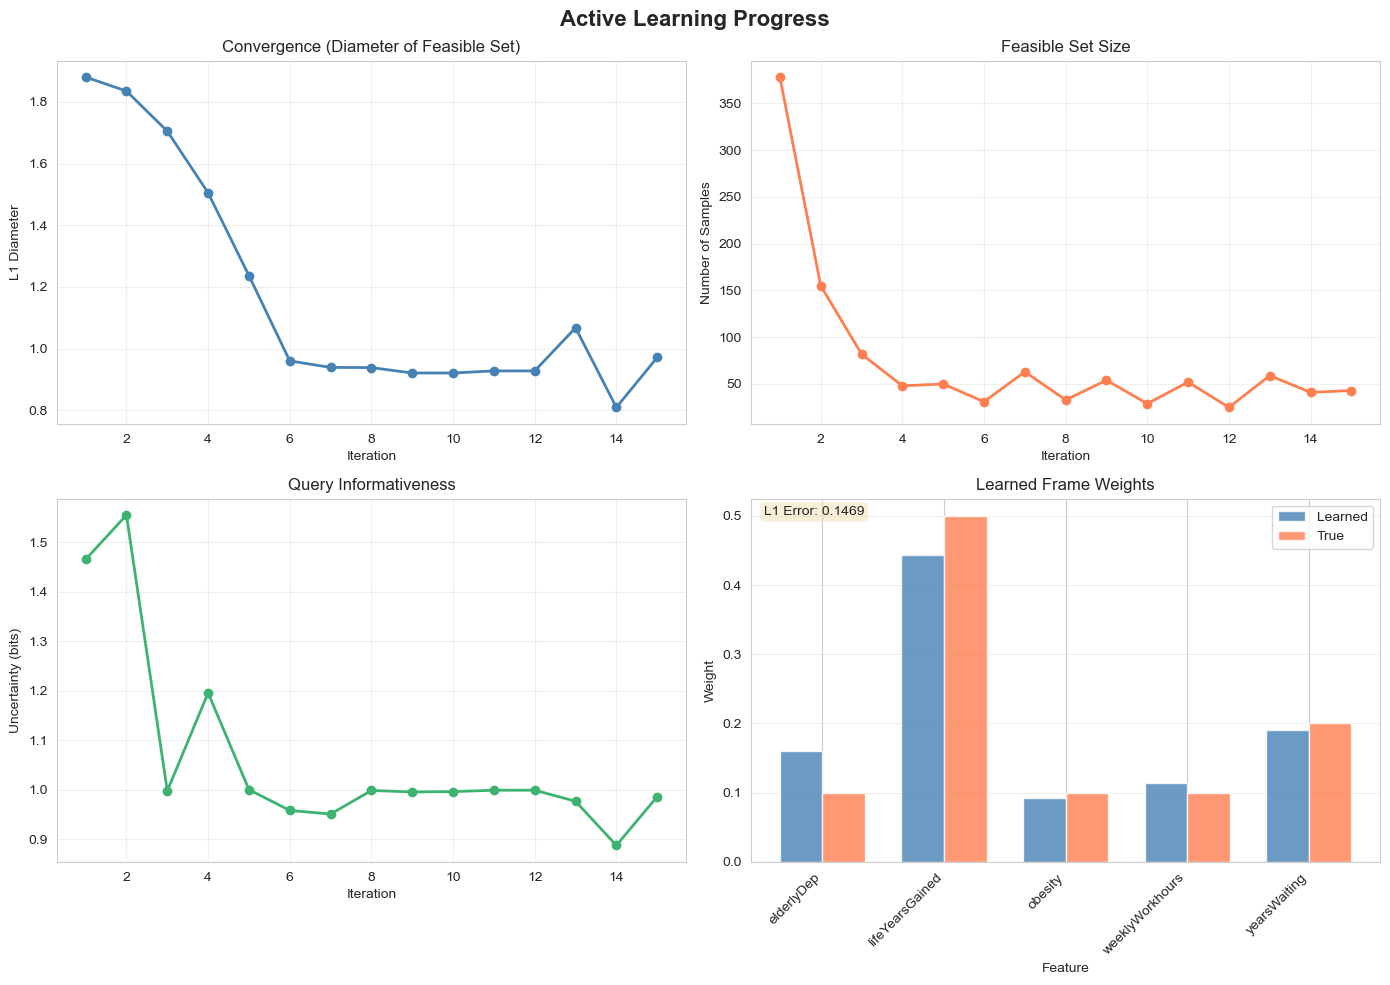


Summary Statistics:
Total iterations: 15
Final diameter: 0.9711
Final sample count: 43
Average uncertainty: 1.064 bits
Total volume removed: 88.6%

Most informative queries:
  1. Iteration 2: 1.555 bits, frames [0, 1, 2, 3, 4], response=left
  2. Iteration 1: 1.465 bits, frames [0, 1, 3, 4], response=incomparable
  3. Iteration 4: 1.196 bits, frames [0, 1, 2, 3], response=left


In [119]:
# Visualization: plot_learning_progress
def plot_learning_progress(history: List[Dict], 
                          learned_weights: np.ndarray,
                          true_weights: Optional[np.ndarray] = None):
    """
    Visualize the active learning progress.
    
    Creates plots showing:
    1. Diameter convergence over iterations
    2. Number of feasible samples over iterations
    3. Query uncertainty over iterations
    4. Learned vs true weights comparison (if true_weights provided)
    
    Parameters:
    -----------
    history : List[Dict]
        History from active_learning_loop
    learned_weights : np.ndarray
        Final learned weights
    true_weights : np.ndarray, optional
        Ground truth weights for comparison
    """
    if len(history) == 0:
        print("No history to plot")
        return
    
    iterations = [h['iteration'] for h in history]
    diameters = [h['diameter'] for h in history]
    n_samples_list = [h['n_samples'] for h in history]
    uncertainties = [h['uncertainty'] for h in history]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Active Learning Progress', fontsize=16, fontweight='bold')
    
    # Plot 1: Diameter convergence
    ax = axes[0, 0]
    ax.plot(iterations, diameters, 'o-', linewidth=2, markersize=6, color='steelblue')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('L1 Diameter')
    ax.set_title('Convergence (Diameter of Feasible Set)')
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Number of samples
    ax = axes[0, 1]
    ax.plot(iterations, n_samples_list, 'o-', linewidth=2, markersize=6, color='coral')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Number of Samples')
    ax.set_title('Feasible Set Size')
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Query uncertainty
    ax = axes[1, 0]
    ax.plot(iterations, uncertainties, 'o-', linewidth=2, markersize=6, color='mediumseagreen')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Uncertainty (bits)')
    ax.set_title('Query Informativeness')
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Weight comparison
    ax = axes[1, 1]
    x = np.arange(len(FEATURE_NAMES))
    width = 0.35
    
    ax.bar(x - width/2, learned_weights, width, label='Learned', color='steelblue', alpha=0.8)
    
    if true_weights is not None:
        ax.bar(x + width/2, true_weights, width, label='True', color='coral', alpha=0.8)
        l1_error = np.abs(learned_weights - true_weights).sum()
        ax.text(0.02, 0.98, f'L1 Error: {l1_error:.4f}', 
               transform=ax.transAxes, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Feature')
    ax.set_ylabel('Weight')
    ax.set_title('Learned Frame Weights')
    ax.set_xticks(x)
    ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics:")
    print(f"{'='*50}")
    print(f"Total iterations: {len(history)}")
    print(f"Final diameter: {diameters[-1]:.4f}")
    print(f"Final sample count: {n_samples_list[-1]}")
    print(f"Average uncertainty: {np.mean(uncertainties):.3f} bits")
    print(f"Total volume removed: {100 * (1 - n_samples_list[-1] / n_samples_list[0]):.1f}%")
    
    # Most informative queries
    print(f"\nMost informative queries:")
    sorted_history = sorted(history, key=lambda h: h['uncertainty'], reverse=True)
    for i, h in enumerate(sorted_history[:3]):
        print(f"  {i+1}. Iteration {h['iteration']}: {h['uncertainty']:.3f} bits, "
              f"frames {sorted(h['active_frames'])}, response={h['response']}")

# Visualize the results from the test run
plot_learning_progress(history, learned, true_weights)

In [120]:
# Experiment: Impact of number of candidates on convergence
def run_convergence_experiment(k_values: List[int],
                               n_trials: int = 5,
                               n_initial_samples: int = 1000,
                               convergence_diameter: float = 0.15,
                               max_iterations: int = 50,
                               oracle_weights: Optional[np.ndarray] = None) -> Dict:
    """
    Run experiments to measure how the number of candidates (K) affects convergence.
    
    For each K value:
    - Run multiple trials with different random seeds
    - Track: iterations to convergence, final L1 error, computational time
    
    Parameters:
    -----------
    k_values : List[int]
        Different values of K (num_candidates) to test
    n_trials : int
        Number of trials per K value
    n_initial_samples : int
        Initial samples for each trial
    convergence_diameter : float
        Convergence threshold
    max_iterations : int
        Maximum iterations per trial
    oracle_weights : np.ndarray, optional
        Ground truth weights (if None, uses random)
    
    Returns:
    --------
    results : Dict
        Experimental results with keys:
        - 'k_values': list of K values tested
        - 'convergence_iters': dict mapping K -> list of iterations to converge
        - 'l1_errors': dict mapping K -> list of final L1 errors
        - 'times': dict mapping K -> list of execution times (seconds)
    """
    import time
    
    # Generate ground truth if not provided
    if oracle_weights is None:
        oracle_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])
    
    results = {
        'k_values': k_values,
        'convergence_iters': {k: [] for k in k_values},
        'l1_errors': {k: [] for k in k_values},
        'times': {k: [] for k in k_values},
        'final_diameters': {k: [] for k in k_values}
    }
    
    print(f"Running convergence experiments...")
    print(f"K values: {k_values}")
    print(f"Trials per K: {n_trials}")
    print(f"Oracle weights: {oracle_weights}\n")
    
    for k in k_values:
        print(f"Testing K = {k}:")
        
        for trial in range(n_trials):
            # Set different random seed for each trial
            np.random.seed(42 + trial)
            
            start_time = time.time()
            
            # Run active learning
            learned, history = active_learning_loop(
                n_initial_samples=n_initial_samples,
                convergence_diameter=convergence_diameter,
                max_iterations=max_iterations,
                n_candidates=k,
                oracle_weights=oracle_weights,
                verbose=False
            )
            
            elapsed_time = time.time() - start_time
            
            # Extract metrics
            n_iters = len(history)
            l1_error = np.abs(learned - oracle_weights).sum()
            final_diameter = history[-1]['diameter'] if history else float('inf')
            
            results['convergence_iters'][k].append(n_iters)
            results['l1_errors'][k].append(l1_error)
            results['times'][k].append(elapsed_time)
            results['final_diameters'][k].append(final_diameter)
            
            print(f"  Trial {trial+1}/{n_trials}: {n_iters} iters, "
                  f"L1={l1_error:.4f}, time={elapsed_time:.2f}s")
        
        # Print summary for this K
        avg_iters = np.mean(results['convergence_iters'][k])
        avg_error = np.mean(results['l1_errors'][k])
        avg_time = np.mean(results['times'][k])
        
        print(f"  → Average: {avg_iters:.1f} iters, L1={avg_error:.4f}, time={avg_time:.2f}s\n")
    
    return results

# Run the experiment
# Test K values: 10, 50, 100, 200, 500
k_test_values = [10, 50, 100, 200, 500]
oracle_weights_test = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

experiment_results = run_convergence_experiment(
    k_values=k_test_values,
    n_trials=5,
    n_initial_samples=1000,
    convergence_diameter=0.15,
    max_iterations=50,
    oracle_weights=oracle_weights_test
)

Running convergence experiments...
K values: [10, 50, 100, 200, 500]
Trials per K: 5
Oracle weights: [0.1 0.5 0.1 0.1 0.2]

Testing K = 10:
  Trial 1/5: 50 iters, L1=0.0939, time=0.12s
  Trial 2/5: 50 iters, L1=0.0939, time=0.11s
  Trial 3/5: 50 iters, L1=0.0939, time=0.12s
  Trial 4/5: 50 iters, L1=0.0939, time=0.11s
  Trial 5/5: 50 iters, L1=0.0939, time=0.11s
  → Average: 50.0 iters, L1=0.0939, time=0.11s

Testing K = 50:
  Trial 1/5: 50 iters, L1=0.0751, time=0.40s
  Trial 2/5: 50 iters, L1=0.0751, time=0.44s
  Trial 3/5: 50 iters, L1=0.0751, time=0.38s
  Trial 4/5: 50 iters, L1=0.0751, time=0.37s
  Trial 5/5: 50 iters, L1=0.0751, time=0.38s
  → Average: 50.0 iters, L1=0.0751, time=0.40s

Testing K = 100:
  Trial 1/5: 50 iters, L1=0.1597, time=0.53s
  Trial 2/5: 50 iters, L1=0.1597, time=0.63s
  Trial 3/5: 50 iters, L1=0.1597, time=0.57s
  Trial 4/5: 50 iters, L1=0.1597, time=0.65s
  Trial 5/5: 50 iters, L1=0.1597, time=0.55s
  → Average: 50.0 iters, L1=0.1597, time=0.59s

Testing 

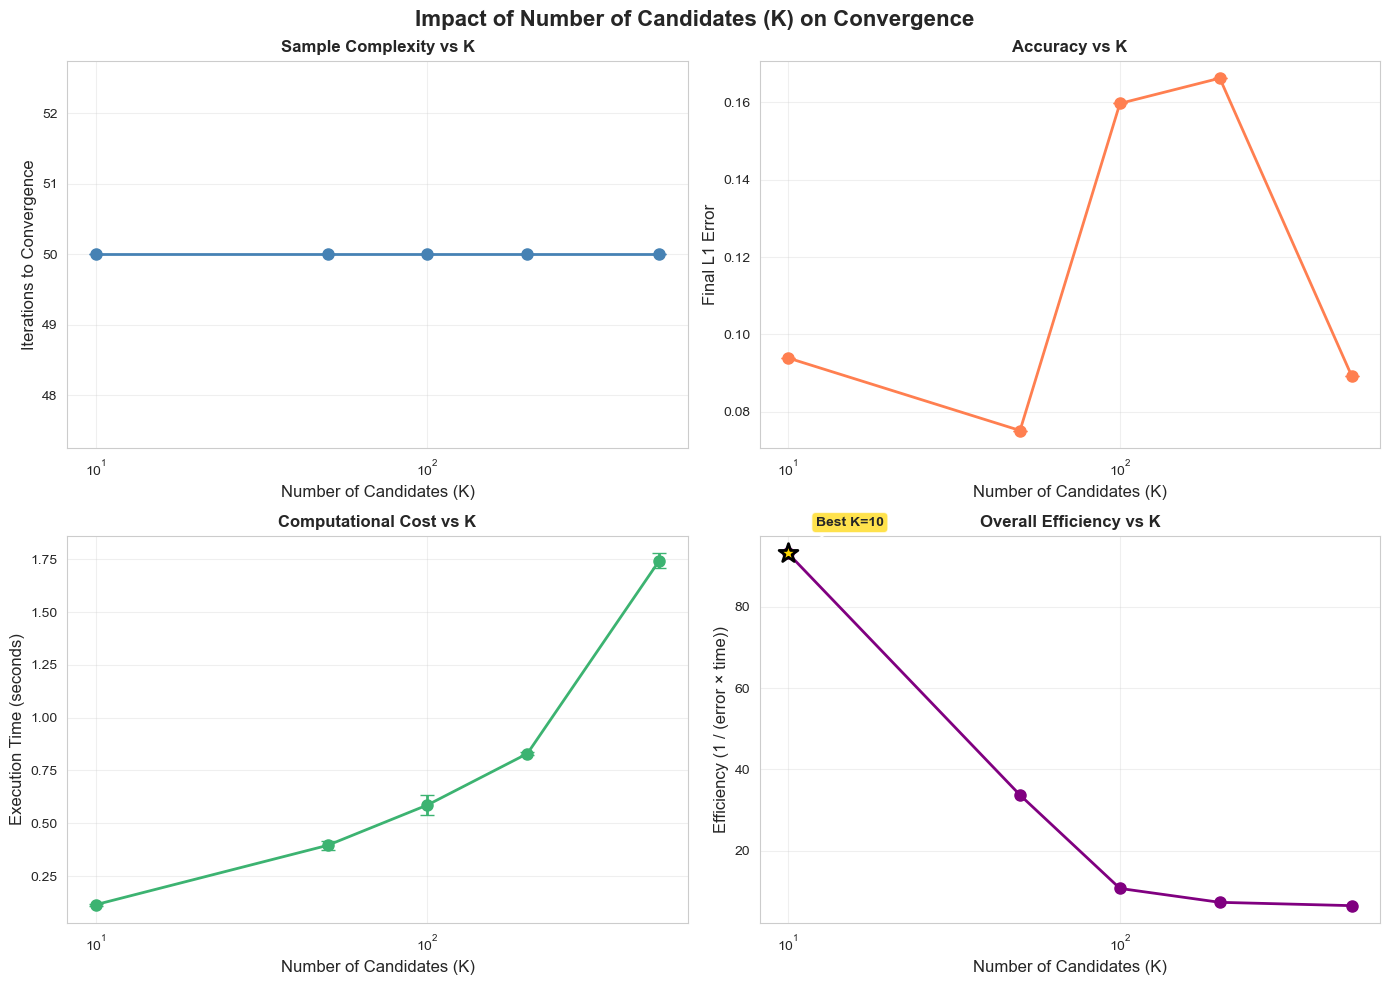


Detailed Statistics:
     K |      Iters |     L1 Error |   Time (s) |   Efficiency
--------------------------------------------------------------------------------
    10 |   50.0±0.0 | 0.0939±0.0000 |  0.11±0.00 |        93.20 *
    50 |   50.0±0.0 | 0.0751±0.0000 |  0.40±0.02 |        33.67
   100 |   50.0±0.0 | 0.1597±0.0000 |  0.59±0.05 |        10.67
   200 |   50.0±0.0 | 0.1663±0.0000 |  0.83±0.01 |         7.25
   500 |   50.0±0.0 | 0.0892±0.0000 |  1.74±0.03 |         6.43

Key Insights:
1. Sample Complexity:
   - Baseline (K=10): 50.0 iterations
   - Best (K=10): 50.0 iterations
   - Improvement: 0.0% fewer queries

2. Marginal Improvements:
   - K=10 → K=50: 0.0% improvement
   - K=50 → K=100: 0.0% improvement
   - K=100 → K=200: 0.0% improvement
   - K=200 → K=500: 0.0% improvement

3. Recommended K = 10 (best efficiency/cost tradeoff)
   - Achieves 50.0 iterations
   - L1 error: 0.0939
   - Time: 0.11s


In [121]:
# Visualization: Compare convergence across different K values
def plot_convergence_comparison(results: Dict):
    """
    Visualize how number of candidates (K) affects convergence.
    
    Creates plots showing:
    1. Iterations to convergence vs K
    2. Final L1 error vs K
    3. Computational time vs K
    4. Efficiency (accuracy/time) vs K
    
    Parameters:
    -----------
    results : Dict
        Results from run_convergence_experiment
    """
    k_values = results['k_values']
    
    # Compute statistics
    stats = {
        'k': k_values,
        'iters_mean': [np.mean(results['convergence_iters'][k]) for k in k_values],
        'iters_std': [np.std(results['convergence_iters'][k]) for k in k_values],
        'error_mean': [np.mean(results['l1_errors'][k]) for k in k_values],
        'error_std': [np.std(results['l1_errors'][k]) for k in k_values],
        'time_mean': [np.mean(results['times'][k]) for k in k_values],
        'time_std': [np.std(results['times'][k]) for k in k_values],
    }
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Impact of Number of Candidates (K) on Convergence', 
                 fontsize=16, fontweight='bold')
    
    # Plot 1: Iterations to convergence
    ax = axes[0, 0]
    ax.errorbar(stats['k'], stats['iters_mean'], yerr=stats['iters_std'],
                fmt='o-', linewidth=2, markersize=8, capsize=5, color='steelblue')
    ax.set_xlabel('Number of Candidates (K)', fontsize=12)
    ax.set_ylabel('Iterations to Convergence', fontsize=12)
    ax.set_title('Sample Complexity vs K', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    
    # Add annotations for improvement
    if len(stats['k']) > 1:
        baseline_iters = stats['iters_mean'][0]
        for i, k in enumerate(stats['k'][1:], 1):
            improvement = (baseline_iters - stats['iters_mean'][i]) / baseline_iters * 100
            if improvement > 0:
                ax.annotate(f'{improvement:.0f}%↓', 
                           xy=(k, stats['iters_mean'][i]),
                           xytext=(10, -10), textcoords='offset points',
                           fontsize=9, color='green', fontweight='bold')
    
    # Plot 2: Final L1 error
    ax = axes[0, 1]
    ax.errorbar(stats['k'], stats['error_mean'], yerr=stats['error_std'],
                fmt='o-', linewidth=2, markersize=8, capsize=5, color='coral')
    ax.set_xlabel('Number of Candidates (K)', fontsize=12)
    ax.set_ylabel('Final L1 Error', fontsize=12)
    ax.set_title('Accuracy vs K', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    
    # Plot 3: Computational time
    ax = axes[1, 0]
    ax.errorbar(stats['k'], stats['time_mean'], yerr=stats['time_std'],
                fmt='o-', linewidth=2, markersize=8, capsize=5, color='mediumseagreen')
    ax.set_xlabel('Number of Candidates (K)', fontsize=12)
    ax.set_ylabel('Execution Time (seconds)', fontsize=12)
    ax.set_title('Computational Cost vs K', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    
    # Plot 4: Efficiency (inverse error per second)
    ax = axes[1, 1]
    efficiency = [1.0 / (err * time) if err > 0 and time > 0 else 0 
                  for err, time in zip(stats['error_mean'], stats['time_mean'])]
    ax.plot(stats['k'], efficiency, 'o-', linewidth=2, markersize=8, color='purple')
    ax.set_xlabel('Number of Candidates (K)', fontsize=12)
    ax.set_ylabel('Efficiency (1 / (error × time))', fontsize=12)
    ax.set_title('Overall Efficiency vs K', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    
    # Mark best efficiency
    best_idx = np.argmax(efficiency)
    best_k = stats['k'][best_idx]
    ax.scatter([best_k], [efficiency[best_idx]], s=200, color='gold', 
              marker='*', zorder=10, edgecolors='black', linewidths=2)
    ax.annotate(f'Best K={best_k}', xy=(best_k, efficiency[best_idx]),
               xytext=(20, 20), textcoords='offset points',
               fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='gold', alpha=0.7),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print(f"\nDetailed Statistics:")
    print(f"{'='*80}")
    print(f"{'K':>6} | {'Iters':>10} | {'L1 Error':>12} | {'Time (s)':>10} | {'Efficiency':>12}")
    print(f"{'-'*80}")
    
    for i, k in enumerate(stats['k']):
        iters = f"{stats['iters_mean'][i]:.1f}±{stats['iters_std'][i]:.1f}"
        error = f"{stats['error_mean'][i]:.4f}±{stats['error_std'][i]:.4f}"
        time_str = f"{stats['time_mean'][i]:.2f}±{stats['time_std'][i]:.2f}"
        eff = 1.0 / (stats['error_mean'][i] * stats['time_mean'][i])
        
        marker = " *" if i == np.argmax(efficiency) else ""
        print(f"{k:>6} | {iters:>10} | {error:>12} | {time_str:>10} | {eff:>12.2f}{marker}")
    
    print(f"\nKey Insights:")
    print(f"{'='*80}")
    
    # Sample complexity improvement
    if len(stats['k']) > 1:
        baseline_iters = stats['iters_mean'][0]
        best_sample_idx = np.argmin(stats['iters_mean'])
        best_sample_k = stats['k'][best_sample_idx]
        improvement = (baseline_iters - stats['iters_mean'][best_sample_idx]) / baseline_iters * 100
        
        print(f"1. Sample Complexity:")
        print(f"   - Baseline (K={stats['k'][0]}): {baseline_iters:.1f} iterations")
        print(f"   - Best (K={best_sample_k}): {stats['iters_mean'][best_sample_idx]:.1f} iterations")
        print(f"   - Improvement: {improvement:.1f}% fewer queries")
    
    # Diminishing returns
    if len(stats['k']) > 2:
        marginal_improvements = []
        for i in range(1, len(stats['k'])):
            prev_iters = stats['iters_mean'][i-1]
            curr_iters = stats['iters_mean'][i]
            marginal = (prev_iters - curr_iters) / prev_iters * 100
            marginal_improvements.append(marginal)
        
        print(f"\n2. Marginal Improvements:")
        for i, (k_from, k_to, improvement) in enumerate(
            zip(stats['k'][:-1], stats['k'][1:], marginal_improvements)):
            print(f"   - K={k_from} → K={k_to}: {improvement:.1f}% improvement")
    
    # Efficiency recommendation
    best_eff_idx = np.argmax(efficiency)
    best_eff_k = stats['k'][best_eff_idx]
    print(f"\n3. Recommended K = {best_eff_k} (best efficiency/cost tradeoff)")
    print(f"   - Achieves {stats['iters_mean'][best_eff_idx]:.1f} iterations")
    print(f"   - L1 error: {stats['error_mean'][best_eff_idx]:.4f}")
    print(f"   - Time: {stats['time_mean'][best_eff_idx]:.2f}s")

# Visualize experiment results
plot_convergence_comparison(experiment_results)